
## Final Project

## Big Data

Ahmed Abu Deiab


Global Port Traffic Analysis (PySpark / Databricks)

Exploratory analysis of global shipping port traffic data using PySpark on Databricks. Course project — Big Data, SGH Warsaw School of Economics, 1st semester.

In [0]:
import os
os.environ["SPARKML_TEMP_DFS_PATH"] = "/Volumes/<catalog_name>/<schema_name>/<volume_name>"

In [0]:
%sql
SHOW CATALOGS

catalog
samples
system
workspace


In [0]:
# File location and type
file_location = "/Workspace/Users/Port_Data.csv"
file_type = "csv"

# CSV options
infer_schema = "true"
first_row_is_header = "true"
delimiter = ","

# The applied options are for CSV files. For other file types, these will be ignored.
df = spark.read.format(file_type) \
  .option("inferSchema", infer_schema) \
  .option("header", first_row_is_header) \
  .option("sep", delimiter) \
  .load(file_location)

temp_table_name = "Port_Data"

df.createOrReplaceTempView(temp_table_name)

display(df)

_c0,Country,Port_Name,UN_Code,Vessels_in_Port,Departures_Last24Hours,Arrivals_Last24Hours,Expected_Arrivals,Type,Area_Local,Area_Global,Also_known_as
0,China,SHANGHAI,CNSHG,2420,1376,1626,644,Port,East China Sea,Central China,"['SHANG HAI', ' YANGSHAN', ' CNSHA', ' CNSGH']"
1,China,NANTONG,CNNTG,1572,1173,1287,234,Port,East China Sea,Central China,['NAN TONG']
2,China,CJK,CNCJK,1529,343,370,310,Anchorage,East China Sea,Central China,"['CHANGJIANGKOU', ' CHANGJIANG KOU', ' CJK CN']"
3,China,NANJING,CNNKG,1414,667,1060,203,Port,East China Sea,Central China,"['NAN JING', ' NAN JIN', ' NANJIN']"
4,China,JIANGYIN,CNJIA,1112,1076,1070,166,Port,East China Sea,Central China,"['-', ' JANG JIN', ' JIANG YIN']"
5,Singapore,SINGAPORE,SGSIN,1109,1682,1748,1205,Port,Singapore Area,Indonesia,"['SPORE', ' SINGPORE', ' SIN EBGA', ' SIN PEBGA']"
6,China,ZHANGJIAGANG,CNZJG,1094,653,608,120,Port,East China Sea,Central China,"['ZHANG JIA GANG', ' ZHANG GIAN GANG', ' ZHAN JIANG']"
7,China,ZHOUSHAN,CNZOS,1064,791,839,463,Port,East China Sea,Central China,"['ZHOU SHAN', ' DINGHAI', ' DING HAI', ' ZHOUSAN']"
8,China,YANGZHOU,CNYZH,945,654,786,47,Port,East China Sea,Central China,['YANG ZHOU']
9,China,TIANJIN,CNTXG,868,409,428,225,Port,Bohai Sea,North China,"['TIAN JIN', ' XINGANG', ' XIN GANG', ' TIANG JIN']"


In [0]:
# Create a view or table

temp_table_name = "Port_Data"

df.createOrReplaceTempView(temp_table_name)

In [0]:
%sql

/* Query the created temp table in a SQL cell */

select * from `Port_Data`

_c0,Country,Port_Name,UN_Code,Vessels_in_Port,Departures_Last24Hours,Arrivals_Last24Hours,Expected_Arrivals,Type,Area_Local,Area_Global,Also_known_as
0,China,SHANGHAI,CNSHG,2420,1376,1626,644,Port,East China Sea,Central China,"['SHANG HAI', ' YANGSHAN', ' CNSHA', ' CNSGH']"
1,China,NANTONG,CNNTG,1572,1173,1287,234,Port,East China Sea,Central China,['NAN TONG']
2,China,CJK,CNCJK,1529,343,370,310,Anchorage,East China Sea,Central China,"['CHANGJIANGKOU', ' CHANGJIANG KOU', ' CJK CN']"
3,China,NANJING,CNNKG,1414,667,1060,203,Port,East China Sea,Central China,"['NAN JING', ' NAN JIN', ' NANJIN']"
4,China,JIANGYIN,CNJIA,1112,1076,1070,166,Port,East China Sea,Central China,"['-', ' JANG JIN', ' JIANG YIN']"
5,Singapore,SINGAPORE,SGSIN,1109,1682,1748,1205,Port,Singapore Area,Indonesia,"['SPORE', ' SINGPORE', ' SIN EBGA', ' SIN PEBGA']"
6,China,ZHANGJIAGANG,CNZJG,1094,653,608,120,Port,East China Sea,Central China,"['ZHANG JIA GANG', ' ZHANG GIAN GANG', ' ZHAN JIANG']"
7,China,ZHOUSHAN,CNZOS,1064,791,839,463,Port,East China Sea,Central China,"['ZHOU SHAN', ' DINGHAI', ' DING HAI', ' ZHOUSAN']"
8,China,YANGZHOU,CNYZH,945,654,786,47,Port,East China Sea,Central China,['YANG ZHOU']
9,China,TIANJIN,CNTXG,868,409,428,225,Port,Bohai Sea,North China,"['TIAN JIN', ' XINGANG', ' XIN GANG', ' TIANG JIN']"


In [0]:
# With this registered as a temp view, it will only be available to this particular notebook. If you'd like other users to be able to query this table, you can also create a table from the DataFrame.
# Once saved, this table will persist across cluster restarts as well as allow various users across different notebooks to query this data.
# To do so, choose your table name and uncomment the bottom line.

permanent_table_name = "Port_Data"

# df.write.format("parquet").saveAsTable(permanent_table_name)

In [0]:
%sql
SELECT
    Country,
    Port_Name,
    MAX(Departures_Last24Hours) AS max_departures_last24h,
    MAX(Arrivals_Last24Hours) AS max_arrivals_last24
FROM
    Port_Data
GROUP BY
    Country, Port_Name;

Country,Port_Name,max_departures_last24h,max_arrivals_last24
China,ZHANGJIAGANG,653,608
China,FANGCHENG,259,336
Singapore,SINGAPORE ANCH,1271,1224
USA,SEATTLE,158,170
China,TIANJIN ANCH,326,408
China,YANTAI,323,325
China,LONGKOU,432,493
China,HUANGHUA,95,114
China,HUIZHOU,72,86
China,YANGPU,75,76


Databricks visualization. Run in Databricks to view.

In [0]:
%sql
select min(Departures_Last24Hours), max(Departures_Last24Hours), avg(Departures_Last24Hours) from Port_Data

min(Departures_Last24Hours),max(Departures_Last24Hours),avg(Departures_Last24Hours)
0,1682,98.98125


Databricks visualization. Run in Databricks to view.

In [0]:
%sql
select min(Arrivals_Last24Hours), max(Arrivals_Last24Hours), avg(Arrivals_Last24Hours) from `Port_Data`

min(Arrivals_Last24Hours),max(Arrivals_Last24Hours),avg(Arrivals_Last24Hours)
1,1748,108.6625


In [0]:
%sql
SELECT
    Country,
    Port_Name,
    MAX(Arrivals_Last24Hours) AS max_arrivals_last24
FROM
    Port_Data
GROUP BY
    Country, Port_Name

Country,Port_Name,max_arrivals_last24
China,ZHANGJIAGANG,608
China,FANGCHENG,336
Singapore,SINGAPORE ANCH,1224
USA,SEATTLE,170
China,TIANJIN ANCH,408
China,YANTAI,325
China,LONGKOU,493
China,HUANGHUA,114
China,HUIZHOU,86
China,YANGPU,76


Databricks visualization. Run in Databricks to view.

In [0]:
%sql
SELECT
    Country,
    Port_Name,
    MAX(Departures_Last24Hours) AS max_departures_last24h
FROM
    Port_Data
GROUP BY
    Country, Port_Name;

Country,Port_Name,max_departures_last24h
China,ZHANGJIAGANG,653
China,FANGCHENG,259
Singapore,SINGAPORE ANCH,1271
USA,SEATTLE,158
China,TIANJIN ANCH,326
China,YANTAI,323
China,LONGKOU,432
China,HUANGHUA,95
China,HUIZHOU,72
China,YANGPU,75


Databricks visualization. Run in Databricks to view.

In [0]:
%sql

SELECT Country,
    sum(Arrivals_Last24Hours) AS Arrivals,
    sum(Expected_Arrivals) AS Expected_Arrivals
FROM
    Port_Data
GROUP BY Country

Country,Arrivals,Expected_Arrivals
Indonesia,592,268
Australia,711,316
Israel,20,20
Togo,14,0
Turkey,1216,199
Romania,18,78
Sweden,238,31
Thailand,155,94
Russia,399,444
Denmark,291,86


Databricks visualization. Run in Databricks to view.

In [0]:
%sql

SELECT Country, count(Port_Name) as Countries_Ports
FROM Port_Data
GROUP BY Country
HAVING count(Port_Name) > 0;

Country,Countries_Ports
Indonesia,8
Australia,13
Israel,1
Togo,1
Turkey,11
Romania,1
Sweden,3
Thailand,4
Russia,12
Denmark,7


Databricks visualization. Run in Databricks to view.

In [0]:
file_path = "/Workspace/Users/Port_Data.csv"  # Replace with the actual path
Port_Data = spark.read.csv(file_path, header=True, inferSchema=True)
 
Port_Data.show()

+---+-----------+-------------+-------+---------------+----------------------+--------------------+-----------------+---------+--------------+-------------------+--------------------+
|_c0|    Country|    Port_Name|UN_Code|Vessels_in_Port|Departures_Last24Hours|Arrivals_Last24Hours|Expected_Arrivals|     Type|    Area_Local|        Area_Global|       Also_known_as|
+---+-----------+-------------+-------+---------------+----------------------+--------------------+-----------------+---------+--------------+-------------------+--------------------+
|  0|      China|     SHANGHAI|  CNSHG|           2420|                  1376|                1626|              644|     Port|East China Sea|      Central China|['SHANG HAI', ' Y...|
|  1|      China|      NANTONG|  CNNTG|           1572|                  1173|                1287|              234|     Port|East China Sea|      Central China|        ['NAN TONG']|
|  2|      China|          CJK|  CNCJK|           1529|                   343|  

In [0]:
Port_Data.describe().show()
 
num_rows = Port_Data.count()
print(f"Number of rows in the dataset: {num_rows}")
distinct_countries = Port_Data.select("Country").distinct()
distinct_countries.show()

+-------+------------------+-------+----------------+-------+-----------------+----------------------+--------------------+------------------+---------+------------+------------------+--------------------+
|summary|               _c0|Country|       Port_Name|UN_Code|  Vessels_in_Port|Departures_Last24Hours|Arrivals_Last24Hours| Expected_Arrivals|     Type|  Area_Local|       Area_Global|       Also_known_as|
+-------+------------------+-------+----------------+-------+-----------------+----------------------+--------------------+------------------+---------+------------+------------------+--------------------+
|  count|               480|    480|             480|    468|              480|                   480|                 480|               480|      480|         480|               480|                 480|
|   mean|             239.5|   NULL|            NULL|   NULL|         153.3125|              98.98125|            108.6625|39.233333333333334|     NULL|        NULL|           

In [0]:
aggregated_data = Port_Data.groupBy("Country").agg({"Vessels_in_Port": "sum"})
aggregated_data.show()

+--------------+--------------------+
|       Country|sum(Vessels_in_Port)|
+--------------+--------------------+
|     Indonesia|                1042|
|     Australia|                1029|
|        Israel|                  62|
|          Togo|                  59|
|        Turkey|                1577|
|       Romania|                 198|
|        Sweden|                 299|
|      Thailand|                 346|
|        Russia|                1172|
|       Denmark|                 486|
|       Bahrain|                 244|
|     Sri Lanka|                  59|
|   Ivory Coast|                  55|
|United Kingdom|                1336|
|    Bangladesh|                 139|
|     Lithuania|                  74|
|       Vietnam|                 611|
|       Hungary|                  93|
|         Macao|                  93|
|          Iran|                  62|
+--------------+--------------------+
only showing top 20 rows


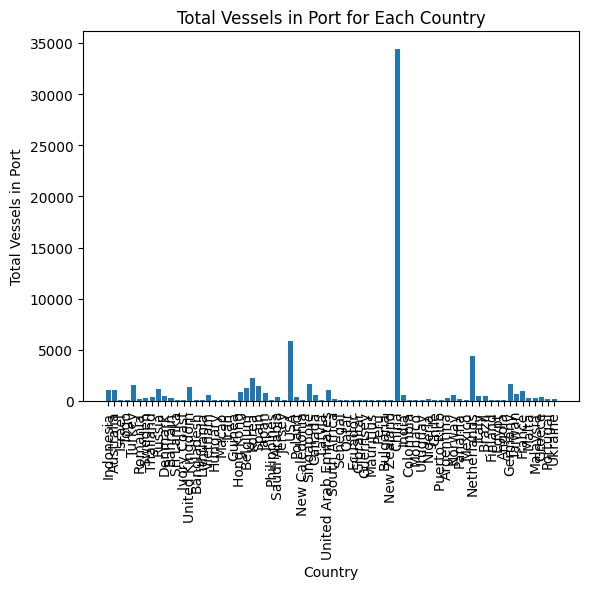

In [0]:
# Plot a bar chart of Vessels_in_Port for each country
import matplotlib.pyplot as plt
 
countries = aggregated_data.toPandas()["Country"]
vessels_count = aggregated_data.toPandas()["sum(Vessels_in_Port)"]
 
plt.bar(countries, vessels_count)
plt.xlabel("Country")
plt.ylabel("Total Vessels in Port")
plt.title("Total Vessels in Port for Each Country")
plt.xticks(rotation='vertical')
plt.show()

+------------------+-----------------+------------------+
|          features|Expected_Arrivals|        prediction|
+------------------+-----------------+------------------+
|  [51.0,23.0,21.0]|               22| 9.422259994953137|
|  [51.0,63.0,61.0]|               22|18.003353358179485|
|  [52.0,21.0,16.0]|                6| 8.803155199539889|
|  [52.0,23.0,26.0]|                0|10.052526293686329|
|  [52.0,24.0,24.0]|                2| 9.959434968022565|
|  [53.0,82.0,94.0]|               57|23.750063516170947|
| [53.0,100.0,97.0]|               54|  26.0734622309007|
|    [54.0,9.0,7.0]|                5| 6.771582915301386|
|  [54.0,29.0,33.0]|               14|11.677366916403402|
|  [54.0,33.0,36.0]|                0|12.432936699477896|
|  [54.0,40.0,30.0]|               11|12.601613845816681|
|[54.0,121.0,100.0]|                7| 28.85039282062049|
|    [55.0,6.0,5.0]|               27| 6.348108998800039|
|  [55.0,13.0,15.0]|               26|  8.15741899710907|
|  [55.0,16.0,

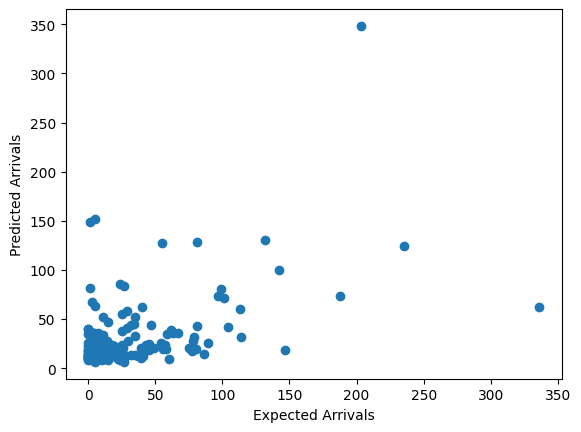

In [0]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression

# Load data from Port_Data table
data = df.select("Vessels_in_Port", "Departures_Last24Hours", "Arrivals_Last24Hours", "Expected_Arrivals")

# Prepare data for ML algorithm
assembler = VectorAssembler(inputCols=["Vessels_in_Port", "Departures_Last24Hours", "Arrivals_Last24Hours"], outputCol="features")
data = assembler.transform(data).select("features", "Expected_Arrivals")

# Split data into training and test sets
train_data, test_data = data.randomSplit([0.7, 0.3])

# Train a linear regression model
lr = LinearRegression(featuresCol="features", labelCol="Expected_Arrivals")
model = lr.fit(train_data)

# Evaluate the model on test data
predictions = model.transform(test_data)
predictions.show()

# Visualize the model
import matplotlib.pyplot as plt
plt.scatter(predictions.select("Expected_Arrivals").collect(), predictions.select("prediction").collect())
plt.xlabel("Expected Arrivals")
plt.ylabel("Predicted Arrivals")
plt.show()

In [0]:
df.createOrReplaceTempView("Port_Data")

In [0]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

# Load data
data = df.select("Vessels_in_Port", "Departures_Last24Hours", "Arrivals_Last24Hours", "Expected_Arrivals")

# Prepare data for ML algorithm
assembler = VectorAssembler(inputCols=["Vessels_in_Port", "Departures_Last24Hours", "Arrivals_Last24Hours"], outputCol="features")
data = assembler.transform(data).select("features", "Expected_Arrivals")

# Split data into training and test sets
train_data, test_data = data.randomSplit([0.7, 0.3], seed=42)

# Define and fit the linear regression model directly
lr = LinearRegression(featuresCol="features", labelCol="Expected_Arrivals")
model = lr.fit(train_data)

# Evaluate the model on test data
predictions = model.transform(test_data)
predictions.select("features", "Expected_Arrivals", "prediction").show()

# Evaluate the model using RMSE
evaluator = RegressionEvaluator(predictionCol="prediction", labelCol="Expected_Arrivals", metricName="rmse")
rmse = evaluator.evaluate(predictions)
print("Root Mean Squared Error = %f" % rmse)

# Also report R² for context — RMSE alone is hard to interpret without it
r2 = model.summary.r2
print("R-squared = %f" % r2)

+------------------+-----------------+------------------+
|          features|Expected_Arrivals|        prediction|
+------------------+-----------------+------------------+
|  [51.0,23.0,21.0]|               22| 19.80881308813329|
|    [52.0,4.0,5.0]|               22| 18.51041736639811|
|    [52.0,5.0,3.0]|               18|19.521942371288045|
|    [52.0,6.0,5.0]|                4|19.220575376423266|
|  [52.0,23.0,26.0]|                0|18.364235462924878|
|  [52.0,24.0,24.0]|                2|19.375760467814814|
|  [52.0,26.0,31.0]|                0|17.788357478269223|
|  [52.0,74.0,85.0]|               26|17.108107722184428|
|  [53.0,19.0,22.0]|               32|18.453348817114247|
|  [53.0,22.0,20.0]|                0|20.175031832029347|
|  [53.0,22.0,39.0]|                0|13.938794833194448|
|  [53.0,82.0,94.0]|               57|17.191270137321936|
| [53.0,100.0,97.0]|               54| 22.59802322773234|
|    [54.0,9.0,7.0]|                5|20.022441140553603|
|  [54.0,17.0,

Coefficients: [1.0860586458150412] Intercept: 1.819024236366709
RMSE on test data = 23.877354


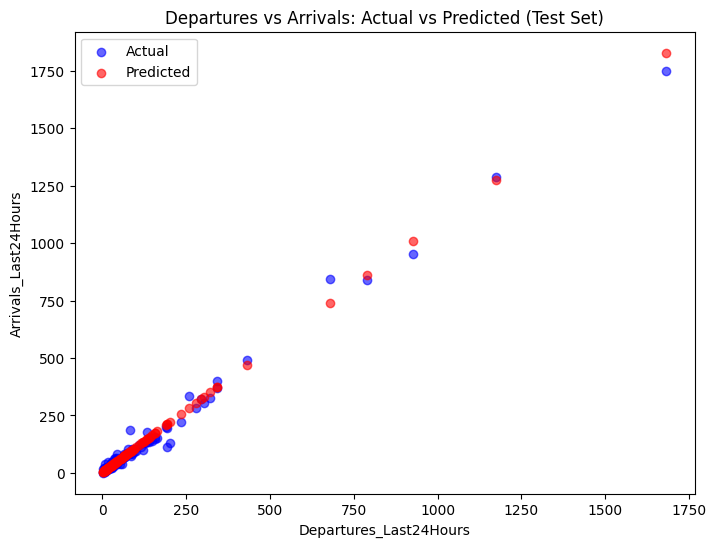

In [0]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
import matplotlib.pyplot as plt

# Prepare the data
assembler = VectorAssembler(inputCols=["Departures_Last24Hours"], outputCol="features")
output = assembler.transform(df)
final_data = output.select("features", "Departures_Last24Hours", "Arrivals_Last24Hours")

# Split the data into training and test sets
train_data, test_data = final_data.randomSplit([0.7, 0.3], seed=42)

# Create and fit a Linear Regression model
lr = LinearRegression(featuresCol="features", labelCol="Arrivals_Last24Hours")
lr_model = lr.fit(train_data)

print("Coefficients: {} Intercept: {}".format(lr_model.coefficients, lr_model.intercept))

# Predict on test data
predictions = lr_model.transform(test_data)

# Evaluate
evaluator = RegressionEvaluator(predictionCol="prediction", labelCol="Arrivals_Last24Hours", metricName="rmse")
rmse = evaluator.evaluate(predictions)
print("RMSE on test data = %f" % rmse)

# Convert to Pandas for plotting — use the original scalar column, not the vector column
pred_pd = predictions.select("Departures_Last24Hours", "Arrivals_Last24Hours", "prediction").toPandas()

plt.figure(figsize=(8, 6))
plt.scatter(pred_pd["Departures_Last24Hours"], pred_pd["Arrivals_Last24Hours"], color='b', label='Actual', alpha=0.6)
plt.scatter(pred_pd["Departures_Last24Hours"], pred_pd["prediction"], color='r', label='Predicted', alpha=0.6)
plt.xlabel("Departures_Last24Hours")
plt.ylabel("Arrivals_Last24Hours")
plt.title("Departures vs Arrivals: Actual vs Predicted (Test Set)")
plt.legend()
plt.show()